# Tutorial: Finding disease-associated cell neighborhoods with scEPS

[scEPS](https://github.com/Genentech/sceps) (single-cell Expression exPlainability
Statistics) combines GWAS statistics with a multi-donor single-cell atlas to answer one
question: **in which cell neighborhoods does variation in disease-gene expression explain
variation in the disease phenotype across donors?**

A *cell neighborhood* is a local region of the k-NN graph, anchored on a single cell. In
each neighborhood, scEPS decomposes the variance of the donor-level phenotype into the part
attributable to GWAS genes, the part attributable to a set of **mean-expression-matched
control genes**, and the part attributable to all remaining genes. This gives, per
neighborhood:

$$
d = \omega^2_{gwas} - \omega^2_{ctrl}
$$

where $\omega^2_{gwas}$ is the phenotypic variance explained *per GWAS gene* and
$\omega^2_{ctrl}$ the same quantity per control gene. The control set matters: highly
expressed genes simply have more expression variance to offer, so comparing GWAS genes
against expression-matched controls is what makes $d$ interpretable. A positive,
significant $d$ says the neighborhood's disease-gene expression tracks the phenotype more
closely than chance expression variation of comparable magnitude would.

The method is described in the [preprint](https://www.medrxiv.org/content/10.64898/2026.06.26.26356714v1);
results for the diseases in the paper can be browsed in the
[result explorer](https://scepsresultexplorer.streamlit.app/).

## Overview

We run scEPS on [OneK1K](https://onek1k.org/) — 1.25M PBMCs from 981 donors — for
**rheumatoid arthritis (RA)**, an immune-mediated disease for which PBMCs are the relevant
tissue.

OneK1K is a healthy population cohort, so it carries no RA case/control status to
decompose. The scEPS paper handles exactly this situation by using a **polygenic risk score
as the phenotype**, and we follow that design: the phenotype is an RA PRS computed from the
donors' own genotypes, and the GWAS genes come from an RA GWAS.

To keep the runtime manageable the tutorial works on a subsample — 100 donors, 5,000 cells,
and a fifth of their cell neighborhoods — so the numbers it prints are illustrative of the
output formats rather than a full analysis. Every subsampling parameter is a variable in the
setup cell.

## Contents

scEPS ships as four command-line tools, one per step. Getting to them takes three
preparation steps, which build the three inputs scEPS needs — and which are the bulk of
this notebook.

**If you already have gene-level GWAS statistics, a donor-level phenotype and a harmonized
`.h5ad`, skip straight to [Step 1](#step-1-sceps-statistics-per-cell-neighborhood).** The
Step 0 sections exist to produce exactly those three things, and they are dominated by
downloads rather than by anything scEPS-specific.

| | Section | Tool | Produces |
| --- | --- | --- | --- |
| | [Setup](#setup) | | parameters, and where the data goes |
| prep | [Step 0a: gene-level GWAS statistics](#step-0a-gene-level-gwas-statistics) | MAGMA | `GENE` and `ZSTAT` per gene |
| prep | [Step 0b: the RA polygenic risk score](#step-0b-the-ra-polygenic-risk-score) | PLINK | `ra_prs`, one value per donor |
| prep | [Step 0c: prepare the single-cell data](#step-0c-prepare-the-single-cell-data) | scanpy | an `.h5ad` with a batch-harmonized k-NN graph |
| scEPS | [Step 1: per-neighborhood statistics](#step-1-sceps-statistics-per-cell-neighborhood) | `sceps` | $d$ and the $\omega^2$ components per cell neighborhood |
| scEPS | [Step 2: neighborhood blocks](#step-2-approximately-independent-neighborhood-blocks) | `sceps-cluster-neighborhood` | approximately independent blocks, for the block bootstrap |
| scEPS | [Step 3: aggregate to cell types](#step-3-aggregate-to-cell-types) | `sceps-aggregate` | mean $d$ per cell type, with standard errors |
| scEPS | [Step 4: correlate with expression](#step-4-correlate-d-with-gene-expression) | `sceps-corr` | genes whose expression tracks $d$ |
| | [Summary](#summary-and-what-changes-for-a-real-study) | | the four commands, and a checklist |

The [scEPS wiki](https://github.com/Genentech/sceps/wiki) is the reference for every option;
this tutorial covers the ones you need to get a first analysis out.

## Setup

scEPS is on PyPI and installs its own command-line tools:

```shell
pip install sceps
```

Two external tools are also needed. **PLINK** must be on `PATH` (`conda install -c bioconda
plink`) — it computes the PRS. **MAGMA** is downloaded by the notebook.

Two Python packages beyond cellink's base dependencies: `pybiomart`, which the MAGMA
pipeline uses to map Entrez gene IDs to the Ensembl IDs the single-cell data uses, and the
`liftover` extra needed by some cellink genotype paths.

```shell
pip install pybiomart "cellink-tools[datasets]"
```

```{important}
Everything this notebook writes — a 4.4 GB expression file, a genotype VCF, PLINK binaries,
MAGMA output, scEPS results — goes to `WORK_DIR`, **not** into the repository. Point it at a
scratch filesystem with ~40 GB free, either by editing the cell below or by setting
`SCEPS_TUTORIAL_WORKDIR`.
```

In [1]:
import gzip
import os
import subprocess
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import yaml

import cellink
from cellink.resources import (
    get_gwas_catalog_study_summary_stats,
    get_onek1k,
    get_pgs_catalog_score,
)
from cellink.tl.external import run_magma_pipeline

sc.settings.verbosity = 1

# ---------------------------------------------------------------------------
# Everything you might want to change lives here.
# ---------------------------------------------------------------------------
SEED = 0

WORK_DIR = Path(os.environ.get("SCEPS_TUTORIAL_WORKDIR", "~/sceps_tutorial_work")).expanduser()
WORK_DIR.mkdir(parents=True, exist_ok=True)

# --- Step 0a: the RA GWAS. European-only, matching OneK1K's ancestry.
RA_GWAS = "GCST90132223"  # Ishigaki 2022, RA: 22,350 cases / 74,823 controls
RA_GWAS_N = 22_350 + 74_823
GWAS_BUILD = "GRCh37"

# --- Step 0b: the PRS. Privé 2022, LDpred2 on UK Biobank, 95,083 variants, European.
RA_PGS_ID = "PGS002088"
# The OneK1K genotypes are GRCh38. Determined empirically, not assumed: the score's
# harmonized GRCh38 positions match 99.1% of its variants against these genotypes, the
# GRCh37 ones only 1.4%. The cell below re-checks the overlap and fails loudly if it is low.
GENO_BUILD = "GRCh38"
MIN_SCORE_OVERLAP = 0.5  # fraction of score variants that must be present

# --- Step 0c: how much of the atlas to keep. OneK1K is 1.25M cells from 981 donors;
# scEPS analyzes one neighborhood per cell and its regression has one row per donor
# *pair*, so a tutorial-sized subsample of both axes is essential.
N_DONORS = 100  # donors kept (scEPS needs >= 20)
N_TOP_CELLTYPES = 6  # most abundant cell types, so Step 3 has enough per type
N_CELLS = 5_000  # cells kept, spread across all retained donors
N_HVG = 2_000  # highly variable genes, flagged for reference (the graph uses X_harmony)
N_NEIGHBORS = 15

# --- Step 1: the phenotype and the donor-level covariates to adjust for.
PHENO = "ra_prs"
# Covariates, following the manuscript: donor age and sex, plus the local cell proportion
# that scEPS computes per neighborhood.
COVAR = "age,sex,sceps.prop_cells_local"
# Fraction of cell neighborhoods to analyze. scEPS keeps each one independently with this
# probability, so ~0.2 x N_CELLS = 1,000 neighborhoods, drawn from across the whole object.
# At ~1.3 s each that is roughly 22 minutes on one core; a real run uses 1.0.
SAMPLE_FRAC = 0.2
# Cell types with fewer analyzed neighborhoods than this are dropped from Step 3's summary:
# too few neighborhoods span too few bootstrap blocks, which collapses the standard error.
MIN_NBHD_PER_CELLTYPE = 25

# Colour scale for the d UMAP, symmetric about zero.
D_COLOR_LIMIT = 0.006

# --- Step 2 / Step 4
N_KMEANS_CLUSTERS = 20  # approximately independent blocks (default 50 assumes more cells)
MIN_NUM_NONZERO = 50  # a gene must be expressed in this many analyzed neighborhoods

# --- Paths. Nothing is written inside the repository.
DATA_HOME = WORK_DIR / "cellink_data"
GENO_DIR = DATA_HOME / "onek1k"
ADATA_PATH = WORK_DIR / "sceps_input.h5ad"
OUT_DIR = WORK_DIR / "sceps_out"
OUT_DIR.mkdir(exist_ok=True)

# configs/magma.yaml ships in the cellink repository, not in the installed package, so
# look for it relative to the notebook and relative to a source checkout.
_magma_config_candidates = [
    Path("../../configs/magma.yaml"),
    Path(cellink.__file__).parents[2] / "configs" / "magma.yaml",
]
MAGMA_CONFIG = next((str(p) for p in _magma_config_candidates if p.exists()), None)
if MAGMA_CONFIG is None:
    raise FileNotFoundError(
        "configs/magma.yaml not found; clone https://github.com/theislab/cellink and point "
        f"MAGMA_CONFIG at its configs/magma.yaml. Looked in: {_magma_config_candidates}"
    )

np.random.seed(SEED)
rng = np.random.default_rng(SEED)
print("WORK_DIR:    ", WORK_DIR)
print("MAGMA_CONFIG:", MAGMA_CONFIG)

[2026-09-26 18:06:09,968] WARNING:cellink.resources._datasets_utils: CELLINK_LIFTOVER_CACHE is not set; using default liftover cache at /home/shih43/.liftover.


/home/shih43/scratch/conda/envs/cellink-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WORK_DIR:     /home/shih43/sceps_work
MAGMA_CONFIG: ../../configs/magma.yaml


Confirm the scEPS command-line tools and PLINK are available:

In [2]:
!sceps --help | head -8
!plink --version

usage: sceps [-h] [--adata ADATA] [--cell-type-col CELL_TYPE_COL]
             [--focal-cell-type FOCAL_CELL_TYPE] [--gene-id-col GENE_ID_COL]
             [--cell-id-col CELL_ID_COL] [--donor-id-col DONOR_ID_COL]
             [--pheno-file PHENO_FILE] [--batch-key BATCH_KEY]
             [--gene-list GENE_LIST] [--control-gene-list CONTROL_GENE_LIST]
             [--focal-cells FOCAL_CELLS] [--total-num-job TOTAL_NUM_JOB]
             [--job-idx JOB_IDX] [--start-idx START_IDX] [--stop-idx STOP_IDX]
             [--min-expr-var-thres MIN_EXPR_VAR_THRES]


PLINK v1.9.0-b.8 64-bit (22 Oct 2024)


## Step 0a. Gene-level GWAS statistics

scEPS needs to know which genes are implicated by the GWAS, and how strongly. It takes this
as a whitespace-delimited text file with two columns it actually reads:

```text
GENE       ZSTAT
```

`GENE` must use the **same identifiers as the single-cell data** — Ensembl IDs here, since
that is what OneK1K's `var_names` are — and `ZSTAT` is the gene-level association
statistic. Everything else in the file is ignored, so MAGMA's output can be passed straight
through.

[MAGMA](https://cncr.nl/research/magma/) produces this in two steps: map SNPs to genes
within a window, then aggregate SNP-level p-values per gene. cellink's
`run_magma_pipeline` wraps both, downloading the 1000 Genomes EUR reference panel and the
gene location file for you.

First the MAGMA binary itself, which is not pip-installable:

In [3]:
import io
import platform
import stat
import zipfile

import requests

MAGMA_DIR = WORK_DIR / "magma"
MAGMA_BIN = MAGMA_DIR / "magma"

if not MAGMA_BIN.exists():
    share_ids = {"Linux": "lxDgt2dNdNr6DYt", "Darwin": "1M1d9vHtVidEwvU"}
    system = platform.system()
    if system not in share_ids:
        raise RuntimeError(f"No known MAGMA v1.10 build for {system!r}; see https://cncr.nl/research/magma/")
    url = f"https://vu.data.surf.nl/public.php/dav/files/{share_ids[system]}"
    MAGMA_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(requests.get(url, timeout=600).content)) as zf:
        zf.extractall(MAGMA_DIR)
    MAGMA_BIN.chmod(MAGMA_BIN.stat().st_mode | stat.S_IEXEC)

print(subprocess.run([str(MAGMA_BIN), "--version"], capture_output=True, text=True).stdout.strip()[:200])

MAGMA version: v1.10 (linux/s)


`get_gwas_catalog_study_summary_stats` fetches harmonized summary statistics from the GWAS
Catalog; `run_magma_pipeline` turns them into gene-level statistics. We use
[GCST90132223](https://www.ebi.ac.uk/gwas/studies/GCST90132223) — Ishigaki et al. (2022),
22,350 cases and 74,823 controls, European-only, which matches OneK1K's ancestry. The
download is large and MAGMA's gene analysis takes a while, so the result is cached on disk
and skipped on re-runs.

In [4]:
# MAGMA needs SNP, CHR, BP and P; map the GWAS Catalog's harmonized names onto them.
# The rsID column is called `variant_id` in these files -- check the column names of your
# own sumstats, since the Catalog's harmonized schema is not identical across studies.
COL_MAPPING = {
    "variant_id": "SNP",
    "chromosome": "CHR",
    "base_pair_location": "BP",
    "p_value": "P",
}

MAGMA_PREFIX = WORK_DIR / "magma_RA"
magma_genes = Path(f"{MAGMA_PREFIX}.genes.out")

if magma_genes.exists():
    print(f"{magma_genes.name} already exists, skipping")
else:
    gwas = get_gwas_catalog_study_summary_stats(RA_GWAS, genome_build=GWAS_BUILD)
    print(f"{gwas.shape[0]:,} variants")

    magma_genes = run_magma_pipeline(
        gwas,
        output_prefix=str(MAGMA_PREFIX),
        col_mapping=COL_MAPPING,
        n_samples=RA_GWAS_N,
        genome_build=GWAS_BUILD,
        gene_id_type="ensembl",  # match OneK1K's var_names
        ld_source="reference_panel",
        reference_panel="EUR",
        config_file=MAGMA_CONFIG,
        magma_bin=str(MAGMA_BIN),
    )

print("gene-level statistics:", magma_genes)

magma_RA.genes.out already exists, skipping
gene-level statistics: /home/shih43/sceps_work/magma_RA.genes.out


MAGMA's output, and the two columns scEPS reads:

In [5]:
genes = pd.read_csv(magma_genes, sep=r"\s+")
print(f"{genes.shape[0]:,} genes")
print(genes.sort_values("P").head(6)[["GENE", "CHR", "NSNPS", "ZSTAT", "P"]].to_string(index=False))

19,129 genes
           GENE  CHR  NSNPS  ZSTAT            P
ENSG00000204296    6   1807  11.11 5.627900e-29
ENSG00000226892    6   1807  11.11 5.627900e-29
ENSG00000237881    6   1807  11.11 5.627900e-29
ENSG00000206310    6   1807  11.11 5.627900e-29
ENSG00000234280    6   1807  11.11 5.627900e-29
ENSG00000236672    6   1807  11.11 5.627900e-29


## Step 0b. The RA polygenic risk score

This is the donor-level phenotype whose variance scEPS decomposes. Three ingredients: the
genotypes, a published set of PRS weights, and PLINK to combine them.

### Step 0b.1 The genotypes

`get_onek1k()` returns a `DonorData` with both modalities, but building the genotype side
means a `vcf2zarr` pass over a genome-wide VCF plus PLINK filtering, pruning and kinship —
and a PRS needs none of that. So we pass `only_download=True`, which fetches the files and
skips all preprocessing, then run just the two PLINK steps a PRS actually requires.

Reading cellink's own config rather than hard-coding URLs means this keeps working if they
change.

In [6]:
onek1k_config = Path(cellink.__file__).parent / "resources" / "config" / "onek1k.yaml"
print("files get_onek1k fetches:", [f["filename"] for f in yaml.safe_load(onek1k_config.read_text())["remote_files"]])

# only_download=True skips the genotype preprocessing (and so needs no vcf2zarr).
# Files already present are verified by checksum and skipped.
get_onek1k(data_home=str(DATA_HOME), only_download=True)

for p in sorted(GENO_DIR.glob("*")):
    if p.is_file():
        print(f"  {p.name:45} {p.stat().st_size / 1e9:6.2f} GB")

files get_onek1k fetches: ['onek1k_cellxgene.h5ad', 'OneK1K.noGP.vcf.gz', 'OneK1K.noGP.vcf.gz.csi', 'gene_counts_Ensembl_105_phenotype_metadata.tsv.gz']


[2026-09-26 18:06:14,225] INFO:root: /home/shih43/sceps_work/cellink_data/onek1k/onek1k_cellxgene.h5ad already exists


[2026-09-26 18:06:14,226] INFO:root: Veryifying checksum


[2026-09-26 18:06:19,319] INFO:root: /home/shih43/sceps_work/cellink_data/onek1k/OneK1K.noGP.vcf.gz already exists


[2026-09-26 18:06:19,320] INFO:root: Veryifying checksum


[2026-09-26 18:06:33,856] INFO:root: /home/shih43/sceps_work/cellink_data/onek1k/OneK1K.noGP.vcf.gz.csi already exists


[2026-09-26 18:06:33,858] INFO:root: Veryifying checksum


[2026-09-26 18:06:33,866] INFO:root: /home/shih43/sceps_work/cellink_data/onek1k/gene_counts_Ensembl_105_phenotype_metadata.tsv.gz already exists


[2026-09-26 18:06:33,867] INFO:root: Veryifying checksum


  OneK1K.noGP.vcf.gz                             12.67 GB
  OneK1K.noGP.vcf.gz.csi                          0.00 GB
  PGS000809.txt.gz                                0.00 GB
  gene_counts_Ensembl_105_phenotype_metadata.tsv.gz   0.00 GB
  onek1k_cellxgene.h5ad                           4.44 GB
  onek1k_prs.bed                                  2.91 GB
  onek1k_prs.bim                                  0.40 GB
  onek1k_prs.fam                                  0.00 GB
  onek1k_prs.log                                  0.00 GB
  onek1k_prs.nosex                                0.00 GB


Convert the VCF to PLINK binary format. cellink's own `preprocess_vcf_to_plink` helper does
this too, but it overwrites the variant IDs with `chrom:pos_ref_alt`; we keep the IDs the
VCF carries, because matching PGS Catalog weights by rsID is the most robust option when
available.

In [7]:
GENO_PREFIX = GENO_DIR / "onek1k_prs"

if not Path(f"{GENO_PREFIX}.bed").exists():
    subprocess.run(
        [
            "plink",
            "--threads",
            "10",
            "--keep-allele-order",
            "--const-fid",
            "--vcf",
            str(GENO_DIR / "OneK1K.noGP.vcf.gz"),
            "--maf",
            "0.01",
            "--make-bed",
            "--out",
            str(GENO_PREFIX),
        ],
        check=True,
    )

bim = pd.read_csv(f"{GENO_PREFIX}.bim", sep=r"\s+", header=None, names=["chrom", "id", "cm", "pos", "a1", "a2"])
fam = pd.read_csv(f"{GENO_PREFIX}.fam", sep=r"\s+", header=None)
frac_rsid = float(bim["id"].astype(str).str.startswith("rs").mean())

print(f"{bim.shape[0]:,} variants x {fam.shape[0]:,} donors")
print("variant ID examples:", bim["id"].head(3).tolist())
print(f"fraction of IDs that are rsIDs: {frac_rsid:.3f}")

10,594,928 variants x 1,098 donors
variant ID examples: ['chr1_58814_G_A', 'chr1_792461_G_A', 'chr1_804849_C_T']
fraction of IDs that are rsIDs: 0.000


### Step 0b.2 The PRS weights

We use [PGS002088](https://www.pgscatalog.org/score/PGS002088/) — an RA score from Privé et
al. (2022), built with LDpred2 on UK Biobank, 95,083 variants, European ancestry.

The genotypes above carry no rsIDs (their IDs are positional, `chr1_58814_G_A`), so the
score has to be matched on chromosome and position — which means the two must be in the
same genome build. PGS Catalog publishes *harmonized* files with positions lifted to a named
build, so we take the one matching the genotypes rather than the author-submitted file,
whose build may differ.

In [8]:
pgs_meta = get_pgs_catalog_score(RA_PGS_ID)
print(f"{pgs_meta['id']}: {pgs_meta['trait_reported']}")
print(f"  variants:        {pgs_meta['variants_number']:,}")
print(f"  submitted build: {pgs_meta['variants_genomebuild']}")
print(f"  weights:         {pgs_meta['weight_type']}")
print(
    f"  reference:       {pgs_meta['publication']['firstauthor']} " f"{pgs_meta['publication']['date_publication'][:4]}"
)
print(f"  harmonized:      {list((pgs_meta.get('ftp_harmonized_scoring_files') or {}).keys())}")

# get_pgs_catalog_score_file fetches the author-submitted file; we want the harmonized one
# for the genotypes' build, so take its URL from the metadata.
harmonized_url = pgs_meta["ftp_harmonized_scoring_files"][GENO_BUILD]["positions"]
pgs_path = WORK_DIR / f"{RA_PGS_ID}_hmPOS_{GENO_BUILD}.txt.gz"
if not pgs_path.exists():
    urlretrieve(harmonized_url, pgs_path)

with gzip.open(pgs_path, "rt") as fh:
    print("\n" + "".join(ln for ln in fh if ln.startswith("#"))[:600])

pgs = pd.read_csv(pgs_path, sep="\t", comment="#", low_memory=False)
print("columns:", list(pgs.columns))
print(pgs[["hm_rsID", "hm_chr", "hm_pos", "effect_allele", "effect_weight"]].head(3).to_string(index=False))

[2026-09-26 18:06:45,068] INFO:root: Fetching https://www.pgscatalog.org/rest/score/PGS002088


PGS002088: Rheumatoid arthritis
  variants:        95,083
  submitted build: GRCh37
  weights:         beta
  reference:       Privé F 2022
  harmonized:      ['GRCh37', 'GRCh38']

###PGS CATALOG SCORING FILE - see https://www.pgscatalog.org/downloads/#dl_ftp_scoring for additional information
#format_version=2.0
##POLYGENIC SCORE (PGS) INFORMATION
#pgs_id=PGS002088
#pgs_name=portability-ldpred2_714.1
#trait_reported=Rheumatoid arthritis
#trait_mapped=rheumatoid arthritis
#trait_efo=MONDO_0008383
#genome_build=GRCh37
#variants_number=95083
#weight_type=beta
##SOURCE INFORMATION
#pgp_id=PGP000263
#citation=Privé F et al. Am J Hum Genet (2022). doi:10.1016/j.ajhg.2021.11.008
##HARMONIZATION DETAILS
#HmPOS_build=GRCh38
#HmPOS_date=2022-08-01
#HmPOS_match_chr={"True": null, 


columns: ['rsID', 'chr_name', 'chr_position', 'effect_allele', 'other_allele', 'effect_weight', 'hm_source', 'hm_rsID', 'hm_chr', 'hm_pos', 'hm_inferOtherAllele']
  hm_rsID hm_chr  hm_pos effect_allele  effect_weight
rs2840532      1 2396376             T   5.036556e-11
rs2645081      1 2397275             G   4.823935e-08
rs3001336      1 2401592             A   3.727476e-08


Build the three-column file PLINK's `--score` wants — variant ID, effect allele, weight —
keyed on the genotypes' own positional IDs. How many variants carry over is the number to
watch: a score that overlaps almost nothing still produces a PRS, just a meaningless one, so
we assert on it rather than trusting it.

In [9]:
bim["key"] = bim["chrom"].astype(str) + ":" + bim["pos"].astype(str)
id_by_key = dict(zip(bim["key"], bim["id"].astype(str), strict=True))

pgs = pgs.dropna(subset=["hm_chr", "hm_pos"]).copy()
pgs["key"] = pgs["hm_chr"].astype(str) + ":" + pgs["hm_pos"].astype(int).astype(str)
pgs["SNP"] = pgs["key"].map(id_by_key)

score_df = pgs.dropna(subset=["SNP"])[["SNP", "effect_allele", "effect_weight"]].copy()
score_df.columns = ["SNP", "A1", "WEIGHT"]

overlap = score_df.shape[0] / pgs.shape[0]
print(f"{score_df.shape[0]:,} of {pgs.shape[0]:,} score variants are in the genotypes ({overlap:.1%})")
if overlap < MIN_SCORE_OVERLAP:
    raise ValueError(
        f"Only {overlap:.1%} of score variants matched. This usually means GENO_BUILD "
        f"({GENO_BUILD}) is not the build of your genotypes -- try the other harmonized file."
    )

SCORE_FILE = WORK_DIR / f"{RA_PGS_ID}.plink_score.txt"
score_df.to_csv(SCORE_FILE, sep="\t", index=False)
score_df.head()

94,237 of 95,083 score variants are in the genotypes (99.1%)


,SNP,A1,WEIGHT
0,chr1_2396376_C_T,T,5.036556e-11
1,chr1_2397275_A_G,G,4.823935e-08
2,chr1_2401592_G_A,A,3.727476e-08
3,chr1_2404237_A_G,G,3.717275e-08
4,chr1_2407130_T_C,C,2.246238e-09


### Step 0b.3 Scoring

`plink --score` sums the dosage-weighted effects per donor. `sum` gives the summed score
rather than the per-allele average; scEPS standardizes the phenotype itself when
`--scale-pheno` is passed, so the scale here does not matter.

In [10]:
PRS_PREFIX = WORK_DIR / "onek1k_ra_prs"
if not Path(f"{PRS_PREFIX}.profile").exists():
    subprocess.run(
        [
            "plink",
            "--threads",
            "10",
            "--bfile",
            str(GENO_PREFIX),
            "--score",
            str(SCORE_FILE),
            "1",
            "2",
            "3",
            "header",
            "sum",
            "--out",
            str(PRS_PREFIX),
        ],
        check=True,
    )

print(open(f"{PRS_PREFIX}.log").read()[-700:])

me/shih43/scratch/sceps_tutorial_work/onek1k_ra_prs.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 1098 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
10594928 variants and 1098 people pass filters and QC.
Note: No phenotypes present.
to allele code mismatch); see
/home/shih43/scratch/sceps_tutorial_work/onek1k_ra_prs.nopred for details.
--score: 94216 valid predictors loaded.
--score: Results written to
/home/shih43/scratch/sceps_tutorial_work/onek1k_ra_prs.profile .

End time: Sat Sep 26 11:19:57 2026



In [11]:
prs = pd.read_csv(f"{PRS_PREFIX}.profile", sep=r"\s+")
score_col = "SCORESUM" if "SCORESUM" in prs.columns else "SCORE"
donor_pheno = prs.rename(columns={"IID": "donor_id", score_col: "ra_prs"})[["donor_id", "ra_prs", "CNT"]].copy()
donor_pheno["ra_prs_z"] = (donor_pheno["ra_prs"] - donor_pheno["ra_prs"].mean()) / donor_pheno["ra_prs"].std()

# CNT counts non-missing *alleles*, so it is twice the number of variants used.
print(f"{donor_pheno.shape[0]:,} donors scored, {int(donor_pheno['CNT'].iloc[0]) // 2:,} variants used per donor")
print(donor_pheno[["ra_prs", "ra_prs_z"]].describe().loc[["mean", "std", "min", "max"]])
donor_pheno.head()

1,098 donors scored, 94,216 variants used per donor
        ra_prs      ra_prs_z
mean  0.004232  2.426717e-17
std   0.003938  1.000000e+00
min  -0.003837 -2.048968e+00
max   0.016777  3.185479e+00


,donor_id,ra_prs,CNT,ra_prs_z
0,OneK1K_1,0.006338,188432,0.534927
1,OneK1K_10,-0.001533,188432,-1.463919
2,OneK1K_100,0.009912,188432,1.442274
3,OneK1K_1000,0.009519,188432,1.342508
4,OneK1K_1001,-0.000364,188432,-1.166976


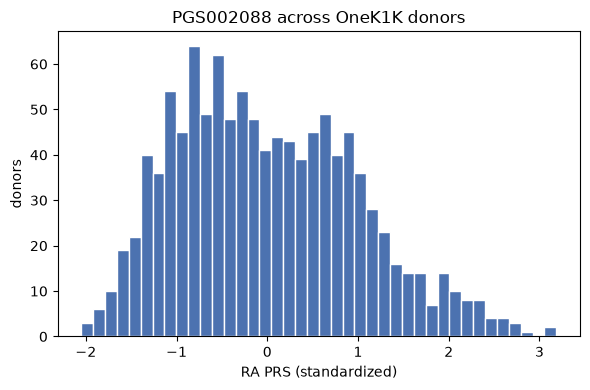

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(donor_pheno["ra_prs_z"], bins=40, color="#4C72B0", edgecolor="white")
ax.set(xlabel="RA PRS (standardized)", ylabel="donors", title=f"{RA_PGS_ID} across OneK1K donors")
plt.tight_layout()
plt.show()

A roughly normal distribution is what a genome-wide score should give.

## Step 0c. Prepare the single-cell data

scEPS reads one `.h5ad` file and expects the following from it:

| Requirement | Why | Here |
| --- | --- | --- |
| ≥ 20 donors with phenotype variation | the variance decomposition is *across donors* | 981 donors, subsampled to 100 |
| a donor ID column in `adata.obs` | groups cells by donor | `donor_id` |
| a donor-level phenotype | the quantity whose variance is decomposed | `ra_prs` from Step 0b |
| a k-NN graph in `adata.obsp["connectivities"]` | defines the neighborhoods | built below |
| a batch-harmonized cell embedding | the graph should be built on it, and Step 2 clusters neighborhoods in it | `X_harmony`, shipped with the dataset |
| a cell type column in `adata.obs` | Step 3 aggregates by it | `celltype` |

Gene and cell identifiers can be left to the index: with `--gene-id-col` / `--cell-id-col`
unset, scEPS uses `adata.var.index` / `adata.obs.index` and calls them `sceps.gene_index` /
`sceps.cell_index`. We rely on that throughout, so the four steps agree on identifiers
without extra bookkeeping.

### Step 0c.1 The full preprocessing recipe (explained)

scEPS assumes QC'd, batch-harmonized data. The scEPS repository ships an example recipe in
`misc/preprocess_scdata.py`, reproduced below; it is *not* executed here because OneK1K
already comes QC'd with a harmonized embedding, and QC thresholds are dataset-specific.

In [13]:
# --- misc/preprocess_scdata.py, for reference (not executed) ---------------
"""
import numpy as np
import scanpy as sc
import scanpy.external as sce

adata = sc.read_h5ad("<raw counts>.h5ad")

# Drop batches with too few cells
batch_nm = "<batch column>"
counts = adata.obs[batch_nm].value_counts()
adata = adata[adata.obs[batch_nm].isin(counts[counts >= 3].index)]

# QC and log-normalization
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=200)
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.pct_counts_mt < 5, :]
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Batch-harmonized embedding and k-NN graph
sc.pp.highly_variable_genes(adata, n_top_genes=2000, inplace=True)
sc.pp.pca(adata, use_highly_variable=True)
sce.pp.harmony_integrate(adata, batch_nm, basis="X_pca", max_iter_harmony=50)
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata)
adata.write_h5ad("harmonized.h5ad")

# Optionally also save a copy with batch regressed out of the expression itself,
# and a copy with no adata.X at all (Steps 2 and 3 only need the graph, so the
# small file keeps their memory use down).
sc.pp.regress_out(adata, keys=[batch_nm])
adata.X = adata.X.astype(np.float32)
adata.write_h5ad("harmonized.regressout.h5ad")

del adata.X
adata.write_h5ad("harmonized.noX.h5ad")
"""

'\nimport numpy as np\nimport scanpy as sc\nimport scanpy.external as sce\n\nadata = sc.read_h5ad("<raw counts>.h5ad")\n\n# Drop batches with too few cells\nbatch_nm = "<batch column>"\ncounts = adata.obs[batch_nm].value_counts()\nadata = adata[adata.obs[batch_nm].isin(counts[counts >= 3].index)]\n\n# QC and log-normalization\nsc.pp.filter_genes(adata, min_cells=3)\nsc.pp.filter_cells(adata, min_genes=200)\nadata.var["mt"] = adata.var_names.str.startswith("MT-")\nsc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)\nadata = adata[adata.obs.pct_counts_mt < 5, :]\nsc.pp.normalize_total(adata, target_sum=1e4)\nsc.pp.log1p(adata)\n\n# Batch-harmonized embedding and k-NN graph\nsc.pp.highly_variable_genes(adata, n_top_genes=2000, inplace=True)\nsc.pp.pca(adata, use_highly_variable=True)\nsce.pp.harmony_integrate(adata, batch_nm, basis="X_pca", max_iter_harmony=50)\nsc.pp.neighbors(adata, use_rep="X_pca_harmony")\nsc.tl.umap(adata)\nadata.write_h5ad(

```{tip}
That recipe writes three files on purpose. Step 1 needs the expression matrix, but Steps 2
and 3 only need the graph and `obs`, so pointing them at the `.noX` copy is the easiest way
to cut memory on a large atlas.
```

### Step 0c.2 Subsampling

Two axes need subsampling. Cells, because scEPS analyzes one neighborhood per cell; and
**donors**, because the method-of-moments regression has one row per donor *pair* — 100
donors give 4,950 rows, but all 981 would give 481,690, far slower per neighborhood without
teaching anything extra. We also keep only the most abundant cell types, so Step 3 has
enough neighborhoods per type to aggregate over.

The atlas is 1.25M cells, so we open it in backed mode and pull only the subsample into
memory.

In [14]:
full = sc.read_h5ad(GENO_DIR / "onek1k_cellxgene.h5ad", backed="r")
celltype_key = "predicted.celltype.l2"
obs = full.obs

print(full)
print(
    "\ndonors:",
    obs["donor_id"].nunique(),
    "| batches:",
    obs["pool_number"].nunique(),
    "| cell types:",
    obs[celltype_key].nunique(),
)
print("disease label:", obs["disease"].value_counts().to_dict())

AnnData object with n_obs × n_vars = 1248980 × 36469 backed at '/home/shih43/sceps_work/cellink_data/onek1k/onek1k_cellxgene.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id', 'pool_number', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'age', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'cell_type_ontology_term_id_colors', 'citation', 'defa

The donor IDs in the expression file and in the genotypes are formatted differently;
`get_onek1k` reconciles them with `"OneK1K_" + donor_id.split("_")[1]` when it builds the
`DonorData`, and we apply the same rule so the PRS joins correctly.

In [15]:
expr_donors = pd.Index(obs["donor_id"].astype(str).unique())
print("expression donor IDs:", expr_donors[:3].tolist())
print("genotype donor IDs:  ", donor_pheno["donor_id"].astype(str).head(3).tolist())

# The same normalization get_onek1k applies when it builds the DonorData.
donor_key = "OneK1K_" + expr_donors.str.split("_").str[1]
expr_to_geno = dict(zip(expr_donors, donor_key, strict=True))

scored = set(donor_pheno["donor_id"].astype(str))
shared = [d for d in expr_donors if expr_to_geno[d] in scored]
print(f"\n{len(shared):,} of {len(expr_donors):,} expression donors have a PRS")

expression donor IDs: ['691_692', '693_694', '688_689']
genotype donor IDs:   ['OneK1K_1', 'OneK1K_10', 'OneK1K_100']

981 of 981 expression donors have a PRS


In [16]:
donors = rng.choice(np.array(shared), size=min(N_DONORS, len(shared)), replace=False)
top_celltypes = obs[celltype_key].value_counts().head(N_TOP_CELLTYPES)
print(top_celltypes)

eligible = np.where(obs["donor_id"].astype(str).isin(donors) & obs[celltype_key].isin(top_celltypes.index))[0]
keep = np.sort(rng.choice(eligible, size=min(N_CELLS, eligible.size), replace=False))
print(f"\n{eligible.size:,} eligible cells -> keeping {keep.size:,}")

adata = full[keep].to_memory()

# A clean column name, so Step 3's output file is not called
# "step3.predicted.celltype.l2.sceps.omega.celltype.txt".
adata.obs["celltype"] = adata.obs[celltype_key].astype(str)

cells_per_donor = adata.obs["donor_id"].value_counts()
cells_per_donor = cells_per_donor[cells_per_donor > 0]
print(f"{adata.n_obs:,} cells x {adata.n_vars:,} genes, {cells_per_donor.size} donors")
print(
    f"cells per donor: min {cells_per_donor.min()}, median {int(cells_per_donor.median())}, max {cells_per_donor.max()}"
)

predicted.celltype.l2
CD4 TCM      289000
CD4 Naive    259012
NK           163202
CD8 TEM      161051
B naive       65702
CD8 Naive     52538
Name: count, dtype: int64



101,063 eligible cells -> keeping 5,000


5,000 cells x 36,469 genes, 100 donors
cells per donor: min 15, median 48, max 101


`X` in this file is raw counts, so normalize and log-transform it, drop genes expressed in
almost no cells, and build the k-NN graph **on `X_harmony`** — the embedding the dataset was
published with.

We flag highly variable genes but do *not* subset to them. scEPS needs the full gene set:
its third variance component is "all remaining genes", and control genes are sampled across
the whole expression range.

In [17]:
print("X max before normalization:", float(adata.X.max()), "(raw counts)" if float(adata.X.max()) > 50 else "")

if float(adata.X.max()) > 50:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

sc.pp.filter_genes(adata, min_cells=10)
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, inplace=True)

# The graph defines the neighborhoods, so it must be built on the batch-harmonized
# embedding -- otherwise neighborhoods track batch rather than biology.
sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, use_rep="X_harmony")

print(f"\n{adata.n_obs:,} cells x {adata.n_vars:,} genes retained")
print("k-NN graph:", adata.obsp["connectivities"].shape)
print("embeddings:", list(adata.obsm.keys()))

X max before normalization: 1845.0 (raw counts)



5,000 cells x 13,026 genes retained
k-NN graph: (5000, 5000)
embeddings: ['X_azimuth_spca', 'X_azimuth_umap', 'X_harmony', 'X_pca', 'X_umap']


### Step 0c.3 The phenotype and covariates

Attach the phenotype. scEPS wants it as a per-cell column that is constant within donor.

Covariates named in `--covar` are regressed out of the phenotype up front, so they must be
**donor-level** — `age` and `sex` already are, straight from the OneK1K metadata. The one
exception is `sceps.prop_cells_local`, which scEPS computes per neighborhood and which is
worth including so a neighborhood's cell abundance does not masquerade as a phenotype
effect. Together these are the covariates the scEPS manuscript adjusts for.

In [18]:
pheno_by_geno_id = donor_pheno.set_index("donor_id")
geno_id = adata.obs["donor_id"].astype(str).map(expr_to_geno)

adata.obs["ra_prs"] = geno_id.map(pheno_by_geno_id["ra_prs_z"]).astype(float)
adata.obs["age"] = adata.obs["age"].astype(float)
adata.obs["sex"] = adata.obs["sex"].astype(str)

# Donors with a missing phenotype would be dropped by scEPS anyway; do it explicitly.
adata = adata[adata.obs["ra_prs"].notna()].copy()

per_donor = adata.obs.groupby("donor_id", observed=True)[["ra_prs", "age"]].first()
print(f"{per_donor.shape[0]} donors with a phenotype")
print(
    f"{PHENO}: mean {per_donor['ra_prs'].mean():.3f}, sd {per_donor['ra_prs'].std():.3f}, "
    f"range {per_donor['ra_prs'].min():.2f} to {per_donor['ra_prs'].max():.2f}"
)
print(f"age: mean {per_donor['age'].mean():.1f}, range {per_donor['age'].min():.0f}-{per_donor['age'].max():.0f}")
print("sex:", adata.obs.groupby("donor_id", observed=True)["sex"].first().value_counts().to_dict())

100 donors with a phenotype
ra_prs: mean 0.066, sd 1.002, range -2.05 to 2.27
age: mean 62.1, range 22-94
sex: {'female': 62, 'male': 38}


In [19]:
adata.write_h5ad(ADATA_PATH)
print(f"{ADATA_PATH} ({ADATA_PATH.stat().st_size / 1e6:.0f} MB)")
print(adata)

... storing 'sex' as categorical


... storing 'celltype' as categorical


/home/shih43/sceps_work/sceps_input.h5ad (53 MB)
AnnData object with n_obs × n_vars = 5000 × 13026
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id', 'pool_number', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'age', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'celltype', 'ra_prs'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

## Step 1. scEPS statistics per cell neighborhood

This is the step that does the work. For each cell in turn, `sceps`:

1. grows a neighborhood around that cell by a random walk on the k-NN graph, expanding until
   it holds enough cells (`--min-num-cell`) and enough donors (`--min-num-donor`,
   `--min-frac-donor`);
2. builds the donor × gene expression matrix for that neighborhood;
3. selects the GWAS genes, and samples control genes matched on mean expression;
4. decomposes the phenotypic variance into GWAS / control / remaining components by method
   of moments, and bootstraps standard errors.

The flags below are the recommended defaults from the wiki:

| Flag | Why |
| --- | --- |
| `--auto-gene-selection` | select GWAS genes by MAGMA FDR rather than a fixed top-N |
| `--scale-pheno` | standardize the phenotype globally before decomposing |
| `--scale-pheno-neighborhood` | standardize again within each neighborhood |
| `--covar` | regress out donor covariates; include `sceps.prop_cells_local` |

### Step 1.1 Sizing the run

Cost scales with the number of neighborhoods (one per cell), the number of donors, and the
number of genes. Analyzing all 5,000 here would take over an hour, so we down-sample with
`--sample-frac`: scEPS keeps each neighborhood independently with that probability, so the
ones analyzed are spread across the whole object.

```{tip}
Prefer `--sample-frac` over `--start-idx` / `--stop-idx` for down-sampling. The index bounds
take a *contiguous* slice, and rows in an `.h5ad` are usually grouped by donor or batch — so
a slice can concentrate every analyzed neighborhood in a handful of donors. Reserve the
index bounds for splitting a full run across parallel jobs, where every slice gets done.
```

```{important}
Every scEPS step exits without recomputing if its output file already exists. That is what
makes a parallel run resumable — but it also means re-running this notebook after changing
`PHENO`, `N_DONORS` or any other setting would silently reuse the previous results. The cell
below clears them first. Set `RESUME = True` to keep them and pick up an interrupted run
instead, or pass `--force-rerun` to an individual `sceps` call.
```

In [20]:
RESUME = False

if RESUME:
    print("RESUME=True: keeping any existing output")
else:
    stale = sorted(p for p in OUT_DIR.glob("step*") if p.is_file())
    for p in stale:
        p.unlink()
    print(f"cleared {len(stale)} previous output file(s)" if stale else "no previous output to clear")

cleared 10 previous output file(s)


### Step 1.2 The run

This is the long cell: roughly 22 minutes with the tutorial's settings.

In [21]:
!sceps \
    --adata {ADATA_PATH} \
    --donor-id-col donor_id \
    --gene-list {magma_genes} \
    --auto-gene-selection \
    --pheno {PHENO} \
    --scale-pheno \
    --scale-pheno-neighborhood \
    --covar "{COVAR}" \
    --sample-frac {SAMPLE_FRAC} \
    --out {OUT_DIR}/step1

2026-09-26 18:07:36,635 - INFO - Loaded 5000 cells for 100 samples


2026-09-26 18:07:36,916 - INFO - 10157 genes after intersecting gene list


2026-09-26 18:07:36,924 - INFO - Selected 2000 genes for analysis


The output file name records the index range scanned — `step1.0-<n_cells>.sceps.omega.txt.gz`
— alongside a `.log` file recording every argument used. Note that the range is the range
*scanned*, not the number analyzed: `--sample-frac` thins within it.

The `.log` file is a plain record of the arguments the run used, worth keeping alongside
results:

In [22]:
log = pd.read_table(next(OUT_DIR.glob("step1.*.log")))
log[
    log["ARGUMENT"].isin(
        [
            "adata",
            "gene_list",
            "pheno",
            "covar",
            "auto_gene_selection",
            "scale_pheno",
            "scale_pheno_neighborhood",
            "min_frac_donor",
            "num_var_comp",
            "num_bootstrap_regression",
            "seed",
        ]
    )
]

,ARGUMENT,VALUE
0,adata,/home/shih43/sceps_work/sceps_input.h5ad
8,gene_list,/home/shih43/sceps_work/magma_RA.genes.out
18,min_frac_donor,0.333333
24,auto_gene_selection,True
35,pheno,ra_prs
36,covar,"age,sex,sceps.prop_cells_local"
37,num_var_comp,3
39,num_bootstrap_regression,1000
42,scale_pheno,True
43,scale_pheno_neighborhood,True


### Step 1.3 Reading the output

One row per cell neighborhood, 37 columns. The ones to look at first:

| Column | Meaning |
| --- | --- |
| `CELL` | the cell the neighborhood is anchored on |
| `NEIGHBORHOOD_SIZE`, `NUM_DONOR` | how many cells / donors the neighborhood ended up with |
| `OMEGA_GWAS`, `OMEGA_CONTROL`, `OMEGA_REST` | variance explained per GWAS / control / remaining gene |
| `OMEGA_DIFF` | the $d$ statistic: `OMEGA_GWAS - OMEGA_CONTROL` |
| `SE_OMEGA_DIFF`, `Z_OMEGA_DIFF`, `P_Z_OMEGA_DIFF` | standard error and test of $d \ne 0$ |

The rest are per-neighborhood diagnostics (mean and variance of expression in each gene set,
gene counts, step size, elapsed time) and the same SE/Z/p triplet for each $\omega^2$
component. The
[wiki](https://github.com/Genentech/sceps/wiki/Step-1.-Estimate-scEPS-statistics-at-each-individual-cell-neighborhood)
documents all of them.

In [23]:
step1 = pd.concat(
    [pd.read_table(p) for p in sorted(OUT_DIR.glob("step1.*.sceps.omega.txt.gz"))],
    ignore_index=True,
)

# Neighborhoods that cannot reach --min-num-cell / --min-num-donor / --min-frac-donor are
# dropped, so fewer rows than requested is normal -- a big shortfall means the QC
# thresholds are too strict for this graph.
expected = int(round(SAMPLE_FRAC * adata.n_obs))
print(
    f"{step1.shape[0]} neighborhoods analyzed (~{expected} expected at "
    f"--sample-frac {SAMPLE_FRAC}), {step1.shape[1]} columns"
)
print(f"anchored in {step1['DONOR_ID'].nunique()} of {adata.obs['donor_id'].nunique()} donors")
print(
    f"median size {step1['NEIGHBORHOOD_SIZE'].median():.0f} cells, "
    f"{step1['NUM_DONOR'].median():.0f} donors "
    f"(random-walk step size: median {step1['STEP_SIZE'].median():.0f})"
)
print(f"{step1['NUM_GENE_GWAS'].iloc[0]:,} GWAS genes, {step1['NUM_GENE_CONTROL'].iloc[0]:,} control genes")

step1[
    [
        "CELL",
        "NUM_DONOR",
        "NEIGHBORHOOD_SIZE",
        "OMEGA_GWAS",
        "OMEGA_CONTROL",
        "OMEGA_DIFF",
        "SE_OMEGA_DIFF",
        "Z_OMEGA_DIFF",
        "P_Z_OMEGA_DIFF",
    ]
].head()

980 neighborhoods analyzed (~1000 expected at --sample-frac 0.2), 37 columns
anchored in 100 of 100 donors
median size 512 cells, 48 donors (random-walk step size: median 4)
708 GWAS genes, 708 control genes


,CELL,NUM_DONOR,NEIGHBORHOOD_SIZE,OMEGA_GWAS,OMEGA_CONTROL,OMEGA_DIFF,SE_OMEGA_DIFF,Z_OMEGA_DIFF,P_Z_OMEGA_DIFF
0,AGTGGGATCATGGTCA-1,46,482,-0.000076,-0.001128,0.001052,0.001117,0.94153,0.35209
1,CAAGGCCCAGGCGATA-1,49,514,-0.001196,-0.000004,-0.001192,0.001018,-1.17090,0.24857
2,CAGAATCCACGCATCG-1,71,787,-0.000614,-0.000633,0.000019,0.000187,0.10165,0.91954
3,CAGCTAAGTGCGCTTG-1,42,490,0.000345,-0.000882,0.001227,0.001237,0.99238,0.32698
4,CATGCCTTCAAGCCTA-1,66,699,-0.000427,0.000287,-0.000714,0.000693,-1.03030,0.30906


```{important}
Sign matters. scEPS counts a neighborhood as disease-associated only when $d > 0$ **and**
$\omega^2_{gwas} > 0$ — disease genes must explain *more* than matched controls, and explain
something in absolute terms. A large negative $d$ is not a hit.
```

Mapping $d$ onto the embedding is how you would look for structure. We use the UMAP the
dataset ships with, so this is the view the OneK1K authors published. The colour scale is
symmetric about zero, so red is where RA genes out-explain their expression-matched
controls and blue is where they do not:

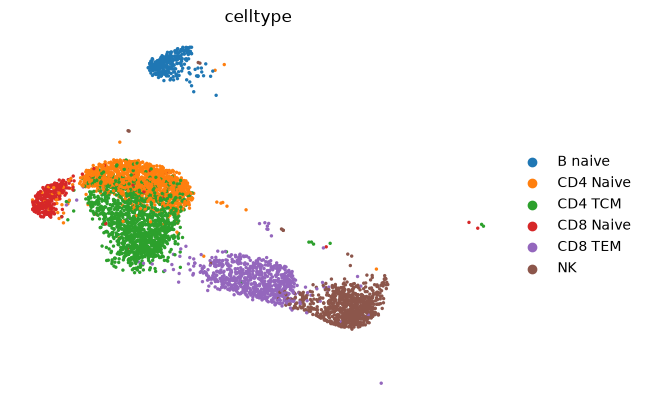

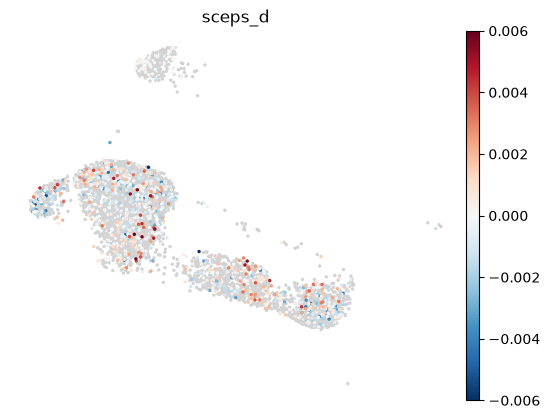

In [24]:
adata.obs["sceps_d"] = adata.obs.index.map(step1.set_index("CELL")["OMEGA_DIFF"])

sc.pl.umap(adata, color="celltype", frameon=False)
sc.pl.umap(
    adata, color="sceps_d", cmap="RdBu_r", vmin=-D_COLOR_LIMIT, vmax=D_COLOR_LIMIT, na_color="lightgrey", frameon=False
)

Grey cells are the neighborhoods `--sample-frac` did not select.

### Step 1.4 Scaling up

A real analysis sets `--sample-frac 1.0` and runs every cell neighborhood, which means
parallelizing. Here the index bounds are the right tool, because every slice gets analyzed:

```shell
# Option 1: let scEPS split the work evenly across N jobs (array job friendly)
sceps ... --total-num-job 100 --job-idx ${SLURM_ARRAY_TASK_ID} --out out/step1

# Option 2: pick the slices yourself, one job each
sceps ... --start-idx 0     --stop-idx 5000  --out out/step1
sceps ... --start-idx 5000  --stop-idx 10000 --out out/step1
```

Either way each job writes its own `step1.<start>-<stop>.*` shard, and Step 3 combines them
by glob. To time a run before committing to it, analyze one small slice with a *separate*
`--out` prefix and read `ELAPSED_TIME` from it — keeping the prefix separate matters, or
Step 3's glob would count those neighborhoods twice.

Other options worth knowing when the run is too slow or too large:

| Option | Effect |
| --- | --- |
| `--use-analytical-stderr` | analytical instead of bootstrap standard errors; faster, at the cost of the bootstrap's robustness |
| `--cell-type-col` + `--focal-cell-type` | analyze one cell type at a time, e.g. one job per type |
| `--force-rerun` | recompute even when output exists |
| `--verbose` | per-neighborhood progress |

```{note}
If you split Step 1 by cell type, Step 2 must still be run **once across all cells**. The
blocks it defines are a property of the graph, not of any one analysis.
```

## Step 2. Approximately independent neighborhood blocks

Neighborhoods overlap: adjacent cells share cells and donors, so their $d$ statistics are
correlated. Averaging them in Step 3 with a naive bootstrap would treat those correlated
estimates as independent and understate the standard error.

`sceps-cluster-neighborhood` fixes this by mini-batch k-means clustering neighborhoods in
the embedding space, giving blocks of neighborhoods with similar donor composition. Step 3
then resamples **blocks** rather than individual neighborhoods.

Only the graph and the embedding are used, so this can run on a stripped-down `.h5ad` with
no `adata.X`. Two flags matter: `--neighbors-use-rep` names the embedding — the same
harmonized one the graph was built on, here `X_harmony` (the default is `X_pca_harmony`, the
name `misc/preprocess_scdata.py` produces) — and `--num-kmeans-cluster` sets the number of
blocks, whose default of 50 assumes far more cells than this subsample has.

In [25]:
!sceps-cluster-neighborhood \
    --adata {ADATA_PATH} \
    --donor-id-col donor_id \
    --neighbors-use-rep X_harmony \
    --num-kmeans-cluster {N_KMEANS_CLUSTERS} \
    --out {OUT_DIR}/step2

2026-09-26 18:30:54,003 - INFO - Loading single-cell data from /home/shih43/sceps_work/sceps_input.h5ad


2026-09-26 18:30:54,144 - INFO - Identifying independent groups of cell neighborhoods
/home/shih43/scratch/conda/envs/cellink-env/lib/python3.12/site-packages/sceps/cli/cluster_neighborhood.py:51: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  av = ad.__version__
/home/shih43/scratch/conda/envs/cellink-env/lib/python3.12/site-packages/sceps/neighborhood.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  av = ad.__version__


In [26]:
blocks = pd.read_table(OUT_DIR / "step2.txt.gz")
print(blocks.head())
print(f"\n{blocks.shape[0]:,} neighborhoods -> {blocks['sceps.neighborhood_cluster'].nunique()} blocks")
print("block sizes:", blocks["sceps.neighborhood_cluster"].value_counts().describe()[["min", "50%", "max"]].to_dict())

     sceps.cell_index  sceps.neighborhood_cluster
0  AAAGATGGTGACGCCT-1                           7
1  AAAGCAAAGCTAACTC-1                          19
2  AAATGCCTCGCAAACT-1                           0
3  AACACGTTCCCTCAGT-1                          14
4  AACTCCCCATCCGCGA-1                           1

5,000 neighborhoods -> 20 blocks
block sizes: {'min': 59.0, '50%': 205.0, 'max': 616.0}


The mapping is keyed on `sceps.cell_index` — the cell identifier scEPS derived from
`adata.obs.index`, which is why leaving `--cell-id-col` unset everywhere keeps the steps
consistent.

## Step 3. Aggregate to cell types

`sceps-aggregate` averages $d$ across groups of neighborhoods and computes standard errors
by bootstrapping the blocks from Step 2. `--prefix` is a glob over the Step 1 shards, so a
sharded run is combined here. Run it once per grouping you care about:

In [27]:
# Per cell type
!sceps-aggregate \
    --prefix "{OUT_DIR}/step1.*.sceps.omega.txt.gz" \
    --adata {ADATA_PATH} \
    --neighborhood-clusters {OUT_DIR}/step2.txt.gz \
    --cell-type-col celltype \
    --out {OUT_DIR}/step3

# Across all analyzed neighborhoods (no --cell-type-col)
!sceps-aggregate \
    --prefix "{OUT_DIR}/step1.*.sceps.omega.txt.gz" \
    --adata {ADATA_PATH} \
    --neighborhood-clusters {OUT_DIR}/step2.txt.gz \
    --out {OUT_DIR}/step3

2026-09-26 18:30:58,811 - INFO - Loading single-cell data from /home/shih43/sceps_work/sceps_input.h5ad


2026-09-26 18:30:58,952 - INFO - Using pre-computed clusters of cell neighborhoods from /home/shih43/sceps_work/sceps_out/step2.txt.gz


2026-09-26 18:30:59,021 - INFO - Aggregating scEPS results across batches of runs
2026-09-26 18:30:59,021 - INFO - Found 1 scEPS score files
2026-09-26 18:30:59,030 - INFO - Testing at cell neighborhood level


2026-09-26 18:30:59,175 - INFO - Testing at cell type level celltype

2026-09-26 18:31:04,033 - INFO - Loading single-cell data from /home/shih43/sceps_work/sceps_input.h5ad


2026-09-26 18:31:04,171 - INFO - Using pre-computed clusters of cell neighborhoods from /home/shih43/sceps_work/sceps_out/step2.txt.gz


2026-09-26 18:31:04,240 - INFO - Aggregating scEPS results across batches of runs
2026-09-26 18:31:04,240 - INFO - Found 1 scEPS score files
2026-09-26 18:31:04,248 - INFO - Testing at cell neighborhood level


Both runs also write `step3.sceps.omega.txt.gz`: the Step 1 shards concatenated, with
FDR-significance flags added across neighborhoods. Step 4 takes that file as its input.

The key columns mirror Step 1, one level up: `MEAN_OMEGA_DIFF` with `SE_`, `Z_` and `P_Z_`
prefixes. In addition, `NUM_SIGNIF_FDR{5,10,20}_OMEGA_DIFF` count how many *individual*
neighborhoods in the group were significant at each FDR threshold — useful for spotting a
cell type where a minority of neighborhoods carry the signal and the mean washes it out.

One thing to watch when only a slice of neighborhoods was analyzed: a cell type contributing
very few of them spans very few bootstrap blocks, so every bootstrap replicate can resample
the same handful and the standard error collapses toward zero — which shows up as an
enormous Z. That is arithmetic, not signal, so we drop those cell types rather than rank
them.

In [28]:
print(sorted(p.name for p in OUT_DIR.glob("step3.*")))

cols = [
    "CELL_TYPE",
    "NUM_CELL",
    "MEAN_NUM_DONOR",
    "MEAN_OMEGA_DIFF",
    "SE_MEAN_OMEGA_DIFF",
    "Z_MEAN_OMEGA_DIFF",
    "P_Z_MEAN_OMEGA_DIFF",
]

by_celltype = pd.read_table(OUT_DIR / "step3.celltype.sceps.omega.celltype.txt")
overall = pd.read_table(OUT_DIR / "step3.sceps.omega.celltype.txt")

# How many analyzed neighborhoods each cell type actually contributed. NUM_CELL counts
# cells of that type, which is not the same thing when only a slice was analyzed.
analyzed = adata.obs.loc[step1["CELL"], "celltype"].value_counts()
by_celltype["N_NBHD"] = by_celltype["CELL_TYPE"].map(analyzed).fillna(0).astype(int)

thin = by_celltype[by_celltype["N_NBHD"] < MIN_NBHD_PER_CELLTYPE]
if not thin.empty:
    print(
        f"\ndropping {thin.shape[0]} cell type(s) with < {MIN_NBHD_PER_CELLTYPE} analyzed "
        f"neighborhoods, where the block bootstrap degenerates:"
    )
    print(thin[["CELL_TYPE", "N_NBHD", "SE_MEAN_OMEGA_DIFF", "Z_MEAN_OMEGA_DIFF"]].to_string(index=False))
by_celltype = by_celltype[by_celltype["N_NBHD"] >= MIN_NBHD_PER_CELLTYPE].reset_index(drop=True)

print("\n=== by cell type ===")
print(by_celltype[["N_NBHD", *cols]].sort_values("Z_MEAN_OMEGA_DIFF", ascending=False).to_string(index=False))
print("\n=== across all analyzed neighborhoods ===")
print(overall[cols].to_string(index=False))

['step3.celltype.sceps.omega.celltype.txt', 'step3.sceps.omega.celltype.txt', 'step3.sceps.omega.txt.gz']



=== by cell type ===
 N_NBHD CELL_TYPE  NUM_CELL  MEAN_NUM_DONOR  MEAN_OMEGA_DIFF  SE_MEAN_OMEGA_DIFF  Z_MEAN_OMEGA_DIFF  P_Z_MEAN_OMEGA_DIFF
    137   CD8 TEM       137          44.883         0.000361            0.000283            1.27760             0.201380
    282   CD4 TCM       282          53.702         0.000046            0.000256            0.17949             0.857550
     67 CD8 Naive        67          48.045        -0.000917            0.000821           -1.11650             0.264220
    177        NK       177          47.130        -0.000490            0.000240           -2.04620             0.040740
    271 CD4 Naive       271          54.502        -0.000504            0.000212           -2.38440             0.017105
     46   B naive        46          97.739        -0.000118            0.000039           -3.03010             0.002444

=== across all analyzed neighborhoods ===
CELL_TYPE  NUM_CELL  MEAN_NUM_DONOR  MEAN_OMEGA_DIFF  SE_MEAN_OMEGA_DIFF  Z_MEAN_OMEGA_D

In [29]:
signif_cols = [
    "CELL_TYPE",
    "NUM_CELL",
    "NUM_SIGNIF_FDR5_OMEGA_DIFF",
    "NUM_SIGNIF_FDR10_OMEGA_DIFF",
    "NUM_SIGNIF_FDR20_OMEGA_DIFF",
]
by_celltype[signif_cols].sort_values("NUM_SIGNIF_FDR20_OMEGA_DIFF", ascending=False)

,CELL_TYPE,NUM_CELL,NUM_SIGNIF_FDR5_OMEGA_DIFF,NUM_SIGNIF_FDR10_OMEGA_DIFF,NUM_SIGNIF_FDR20_OMEGA_DIFF
0,CD8 TEM,137,0,0,0
1,CD4 Naive,271,0,0,0
2,CD4 TCM,282,0,0,0
3,NK,177,0,0,0
4,CD8 Naive,67,0,0,0
5,B naive,46,0,0,0


A forest plot of the per-cell-type estimates is usually the headline figure:

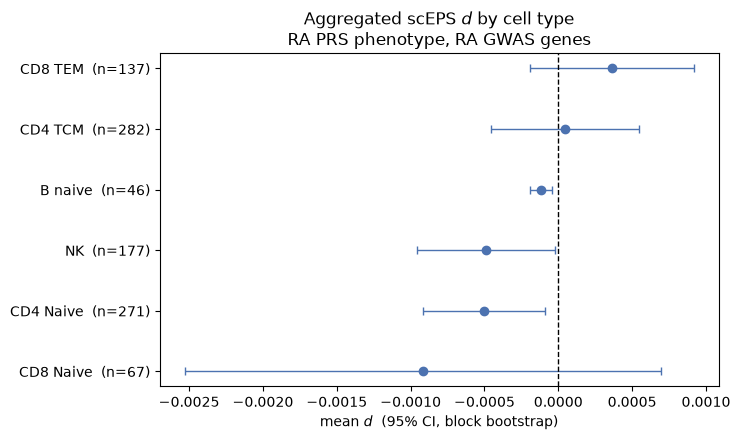

In [30]:
plot_df = by_celltype.sort_values("MEAN_OMEGA_DIFF")
y = np.arange(plot_df.shape[0])

fig, ax = plt.subplots(figsize=(7.5, 0.5 * plot_df.shape[0] + 1.5))
ax.errorbar(
    plot_df["MEAN_OMEGA_DIFF"],
    y,
    xerr=1.96 * plot_df["SE_MEAN_OMEGA_DIFF"],
    fmt="o",
    color="#4C72B0",
    ecolor="#4C72B0",
    capsize=3,
    lw=1,
)
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_yticks(y)
ax.set_yticklabels([f"{ct}  (n={n:,})" for ct, n in zip(plot_df["CELL_TYPE"], plot_df["NUM_CELL"], strict=True)])
ax.set(
    xlabel="mean $d$  (95% CI, block bootstrap)",
    title="Aggregated scEPS $d$ by cell type\nRA PRS phenotype, RA GWAS genes",
)
plt.tight_layout()
plt.show()

Cell types whose interval sits clearly above zero are the candidate populations.

Other options for this step:

| Option | Effect |
| --- | --- |
| `--cell-type-col a,b,c` | aggregate at several resolutions at once, one output file each |
| `--use-inverse-variance-weights` | weight neighborhoods by precision instead of averaging equally |
| `--use-neighborhoods` | aggregate over an explicit list of cell IDs |
| `--add-column NAME VALUE` | stamp a constant column onto the output, handy when merging many runs |
| `--num-bootstrap` | bootstrap replicates (1,000 by default) |

Omitting `--neighborhood-clusters` falls back to an ordinary bootstrap over individual
neighborhoods, which will generally give standard errors that are too small.

## Step 4. Correlate d with gene expression

This step is optional. `sceps-corr` correlates each gene's expression with the scEPS
statistics across neighborhoods (Spearman by default), answering a follow-up question:
having found where the signal is, which genes mark those neighborhoods?

`--min-num-nonzero` drops genes expressed in too few cells. Note that it applies to the
neighborhoods actually analyzed, not the whole atlas — `sceps-corr` intersects the
single-cell data with the scEPS result first — so on a subsampled run it has to come down
from its default of 100.

In [31]:
!sceps-corr \
    --adata {ADATA_PATH} \
    --sceps-result {OUT_DIR}/step3.sceps.omega.txt.gz \
    --min-num-nonzero {MIN_NUM_NONZERO} \
    --out {OUT_DIR}/step4

2026-09-26 18:31:08,261 - INFO - Loading scEPS results from /home/shih43/sceps_work/sceps_out/step3.sceps.omega.txt.gz


In [32]:
step4 = pd.concat(
    [pd.read_table(p) for p in sorted(OUT_DIR.glob("step4.0-*.txt.gz"))],
    ignore_index=True,
).dropna(subset=["R_OMEGA_DIFF"])

# Map Ensembl IDs back to symbols for readability.
symbols = adata.var["feature_name"].astype(str)
step4["SYMBOL"] = step4["GENE"].map(symbols)

print(f"{step4.shape[0]:,} genes correlated\n")
show = ["SYMBOL", "GENE", "R_OMEGA_GWAS", "R_OMEGA_CONTROL", "R_OMEGA_DIFF"]
print("Most positively correlated with d:")
print(step4.nlargest(10, "R_OMEGA_DIFF")[show].to_string(index=False))
print("\nMost negatively correlated with d:")
print(step4.nsmallest(10, "R_OMEGA_DIFF")[show].to_string(index=False))

4,197 genes correlated

Most positively correlated with d:
                 SYMBOL            GENE  R_OMEGA_GWAS  R_OMEGA_CONTROL  R_OMEGA_DIFF
  SMIM8_ENSG00000111850 ENSG00000111850      0.485236        -0.148394      0.465687
 TRIM27_ENSG00000204713 ENSG00000204713      0.200216        -0.275108      0.450216
  OTUD5_ENSG00000068308 ENSG00000068308      0.267772        -0.356178      0.430312
  CNOT8_ENSG00000155508 ENSG00000155508      0.498758        -0.089119      0.391326
TMEM41B_ENSG00000166471 ENSG00000166471      0.312579        -0.301538      0.380181
EPS15L1_ENSG00000127527 ENSG00000127527      0.424154        -0.106555      0.365954
    SP3_ENSG00000172845 ENSG00000172845      0.132028        -0.304442      0.365576
 MRPL37_ENSG00000116221 ENSG00000116221      0.192760        -0.219638      0.363982
  PRKDC_ENSG00000253729 ENSG00000253729      0.249075        -0.298625      0.363247
  SRP54_ENSG00000100883 ENSG00000100883      0.114048        -0.469641      0.359709

Most 

The same restricted to one cell type, via `--cell-type-col` / `--focal-cell-type`. With
fewer neighborhoods in a single cell type, `--min-num-nonzero` has to come down further —
otherwise every gene is filtered out and the tool has nothing to concatenate.

In [33]:
focal = by_celltype.sort_values("Z_MEAN_OMEGA_DIFF", ascending=False)["CELL_TYPE"].iloc[0]
n_focal = int((adata.obs.loc[step1["CELL"], "celltype"] == focal).sum())
focal_min_nonzero = max(5, n_focal // 10)
print(f"focal cell type: {focal} ({n_focal} analyzed neighborhoods) " f"-> --min-num-nonzero {focal_min_nonzero}")

focal cell type: CD8 TEM (137 analyzed neighborhoods) -> --min-num-nonzero 13


In [34]:
!sceps-corr \
    --adata {ADATA_PATH} \
    --sceps-result {OUT_DIR}/step3.sceps.omega.txt.gz \
    --cell-type-col celltype \
    --focal-cell-type "{focal}" \
    --min-num-nonzero {focal_min_nonzero} \
    --out {OUT_DIR}/step4_focal

2026-09-26 18:31:38,082 - INFO - Loading scEPS results from /home/shih43/sceps_work/sceps_out/step3.sceps.omega.txt.gz


In [35]:
step4_focal = pd.concat(
    [pd.read_table(p) for p in sorted(OUT_DIR.glob("step4_focal.*.txt.gz"))],
    ignore_index=True,
).dropna(subset=["R_OMEGA_DIFF"])
step4_focal["SYMBOL"] = step4_focal["GENE"].map(symbols)

print(f"{step4_focal.shape[0]:,} genes correlated within {focal}")
step4_focal.nlargest(10, "R_OMEGA_DIFF")[["SYMBOL", "GENE", "R_OMEGA_GWAS", "R_OMEGA_CONTROL", "R_OMEGA_DIFF"]]

2,425 genes correlated within CD8 TEM


,SYMBOL,GENE,R_OMEGA_GWAS,R_OMEGA_CONTROL,R_OMEGA_DIFF
655,PHAX_ENSG00000164902,ENSG00000164902,0.510989,-0.769231,0.703297
1949,CSNK1D_ENSG00000141551,ENSG00000141551,0.352941,-0.485294,0.691176
1448,ZFC3H1_ENSG00000133858,ENSG00000133858,0.357143,-0.659341,0.686813
1657,BNIP2_ENSG00000140299,ENSG00000140299,0.230769,-0.402198,0.683516
18,MAD2L2_ENSG00000116670,ENSG00000116670,0.494505,-0.483516,0.675824
44,ZNF683_ENSG00000176083,ENSG00000176083,0.657143,-0.539286,0.667857
269,PPM1G_ENSG00000115241,ENSG00000115241,0.321275,-0.380135,0.667076
2172,MYADM_ENSG00000179820,ENSG00000179820,0.560440,-0.571429,0.664835
46,RPS6KA1_ENSG00000117676,ENSG00000117676,0.639560,-0.191209,0.661538
1418,CALCOCO1_ENSG00000012822,ENSG00000012822,0.373529,-0.391176,0.650000


```{warning}
By default `sceps-corr` reports correlations with **no** test statistics, deliberately: both
the scEPS statistics and gene expression are correlated across neighborhoods, which makes a
valid test hard to construct. Adding `--num-bootstrap 1000 --neighborhood-clusters
<step2 output>` produces `SE_`, `Z_` and `P_` columns via block bootstrap, but treat those
p-values as descriptive rather than calibrated.
```

## Summary and what changes for a real study

The whole workflow, as four commands:

```shell
# Step 1 -- per-neighborhood statistics (parallelize over --job-idx)
sceps \
    --adata harmonized.h5ad \
    --donor-id-col donor_id \
    --gene-list magma_RA.genes.out \
    --auto-gene-selection \
    --pheno ra_prs \
    --scale-pheno --scale-pheno-neighborhood \
    --covar "age,sex,sceps.prop_cells_local" \
    --total-num-job 100 --job-idx ${SLURM_ARRAY_TASK_ID} \
    --out out/step1

# Step 2 -- approximately independent blocks (once, across ALL cells)
sceps-cluster-neighborhood \
    --adata harmonized.noX.h5ad \
    --donor-id-col donor_id \
    --neighbors-use-rep X_harmony \
    --out out/step2

# Step 3 -- aggregate to cell types
sceps-aggregate \
    --prefix "out/step1.*.sceps.omega.txt.gz" \
    --adata harmonized.noX.h5ad \
    --neighborhood-clusters out/step2.txt.gz \
    --cell-type-col celltype \
    --out out/step3

# Step 4 -- correlate with gene expression (optional)
sceps-corr \
    --adata harmonized.h5ad \
    --sceps-result out/step3.sceps.omega.txt.gz \
    --out out/step4
```

The wiki suggests one directory per step, which keeps the globs in Steps 3 and 4 simple:

```text
DISEASE/
├── step_0a/out/     # MAGMA gene-level statistics
├── step_0b/out/     # phenotype (PRS, or real disease status)
├── step_0c/out/     # harmonized .h5ad files
├── step1/out/       # one shard per parallel job
├── step2/out/
├── step3/out/
└── step4/out/
```

### Checklist for real data

- **A measured phenotype** when you have one — case/control status or a quantitative trait
  in the same donors. scEPS dummy-codes a two-level phenotype automatically. If it lives
  outside the `.h5ad`, pass it with `--pheno-file` (a table keyed by the same donor ID
  column) rather than merging it in by hand.
- **Check the gene identifiers match** `adata.var_names` — a mismatch yields an empty gene
  set, not an error.
- **Harmonize before building the graph**, and point `--neighbors-use-rep` at the harmonized
  embedding.
- **Donor-level covariates** in `--covar`, and keep `sceps.prop_cells_local` in the list.
- **All cells**, via `--total-num-job` / `--job-idx` as an array job.
- **Bootstrap standard errors** (the default). Reach for `--use-analytical-stderr` only when
  compute is the binding constraint.
- **Interpret the sign**: a hit needs $d > 0$ *and* $\omega^2_{gwas} > 0$.

See the [wiki](https://github.com/Genentech/sceps/wiki) for the full option reference, and
the [preprint](https://www.medrxiv.org/content/10.64898/2026.06.26.26356714v1) for the
method.